In [5]:
import pyarrow as pa
import pyarrow.parquet as pq

parquet_file = "../data/datasets/train.parquet"

table = pq.read_table(parquet_file)

print(table.schema)

seq_ix: int64
step_in_seq: int64
need_prediction: int8
p0: double
p1: double
p2: double
p3: double
p4: double
p5: double
p6: double
p7: double
p8: double
p9: double
p10: double
p11: double
v0: double
v1: double
v2: double
v3: double
v4: double
v5: double
v6: double
v7: double
v8: double
v9: double
v10: double
v11: double
dp0: double
dp1: double
dp2: double
dp3: double
dv0: double
dv1: double
dv2: double
dv3: double
t0: double
t1: double
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 4022


In [15]:
commont_features = ["seq_ix", "step_in_seq"]

bid_price_features = [f"p{i}" for i in range(0, 6)]
ask_price_features = [f"p{i}" for i in range(6, 12)]

bid_price_data = table.select(bid_price_features + commont_features).to_pandas()
ask_price_data = table.select(ask_price_features + commont_features).to_pandas()

print(bid_price_data.head())

         p0        p1        p2        p3        p4        p5  seq_ix  \
0  1.077446 -0.710366  0.373591  0.835558  0.050204 -0.139710       0   
1  1.100140 -0.562796  0.483658  0.875354  0.138444 -0.010037       0   
2  1.100140 -0.562796  0.483658  0.875354  0.138444 -0.010037       0   
3  0.955471 -1.486537  0.230353  0.676854 -0.262686 -0.366873       0   
4  1.025123 -0.832006  0.317650  0.759677 -0.062770 -0.230353       0   

   step_in_seq  
0            0  
1            1  
2            2  
3            3  
4            4  


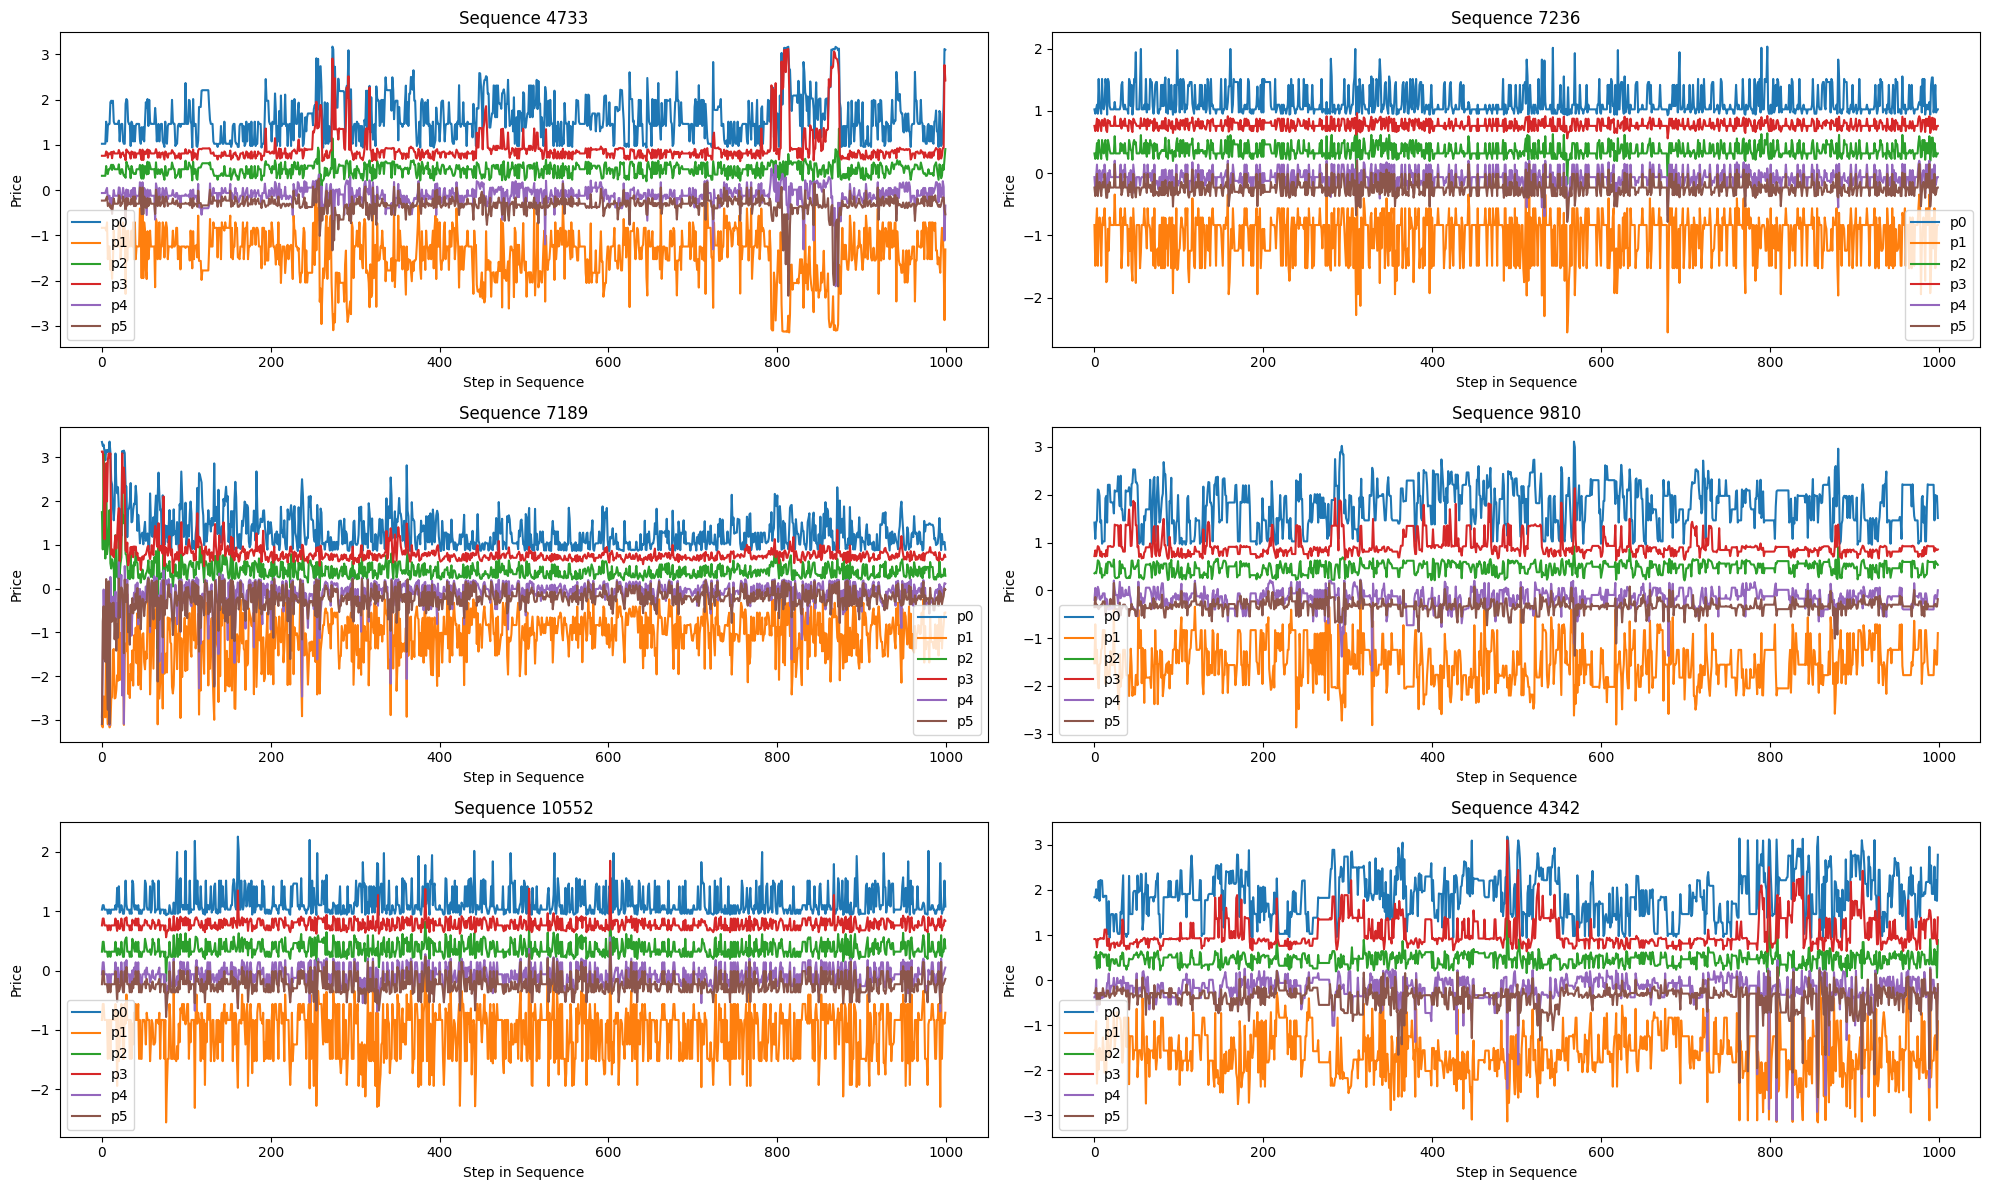

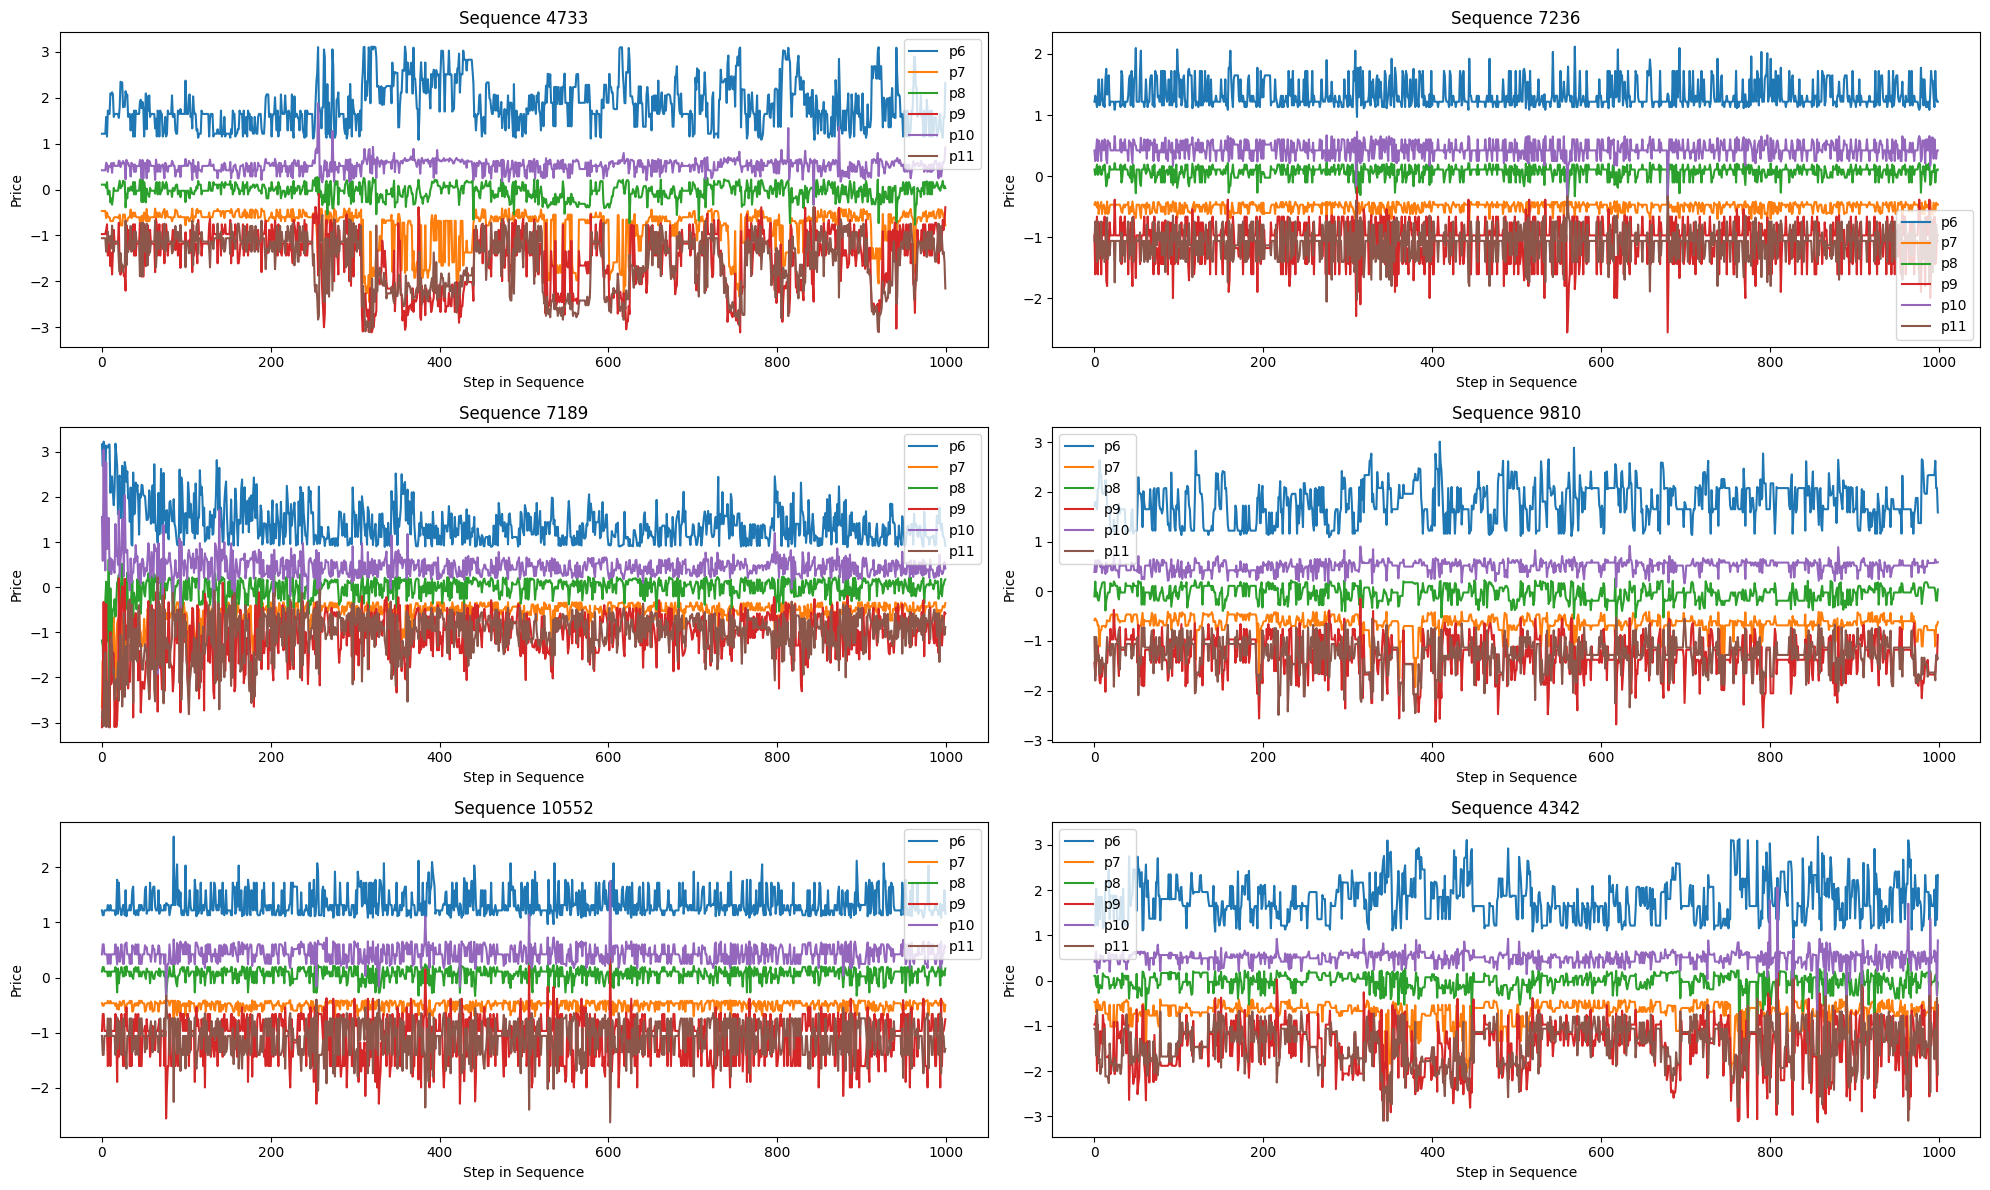

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# set a seed for reproducibility

np.random.seed(42)

random_seq_ix = bid_price_data["seq_ix"].sample(n=6)

fig, ax = plt.subplots(figsize=(20, 12), ncols=2, nrows=3)

for i, r in enumerate(random_seq_ix):
    seq_data = bid_price_data[bid_price_data["seq_ix"] == r]
    
    for f in bid_price_features:
        ax[i // 2, i % 2].plot(seq_data["step_in_seq"], seq_data[f], label=f)

    ax[i // 2, i % 2].set_title(f"Sequence {r}")
    ax[i // 2, i % 2].set_xlabel("Step in Sequence")
    ax[i // 2, i % 2].set_ylabel("Price")
    ax[i // 2, i % 2].legend()

plt.tight_layout()

fig, ax = plt.subplots(figsize=(20, 12), ncols=2, nrows=3)

for i, r in enumerate(random_seq_ix):
    seq_data = ask_price_data[ask_price_data["seq_ix"] == r]
    
    for f in ask_price_features:
        ax[i // 2, i % 2].plot(seq_data["step_in_seq"], seq_data[f], label=f)

    ax[i // 2, i % 2].set_title(f"Sequence {r}")
    ax[i // 2, i % 2].set_xlabel("Step in Sequence")
    ax[i // 2, i % 2].set_ylabel("Price")
    ax[i // 2, i % 2].legend()

plt.tight_layout()


In [19]:
trade_price_features = [f"dp{i}" for i in range(0, 4)]

trade_price_data = table.select(trade_price_features + commont_features).to_pandas()

trade_price_data

,dp0,dp1,dp2,dp3,seq_ix,step_in_seq
0,-0.031078,-0.053527,-0.475214,-0.410787,0,0
1,0.950145,-0.083598,-0.604252,-0.703991,0,1
2,-0.168259,1.632066,-0.178565,0.121240,0,2
3,-0.426942,-0.743530,0.680013,1.394857,0,3
4,0.195700,0.293986,0.494971,0.267884,0,4
...,...,...,...,...,...,...
10720995,-0.094232,-0.193143,-0.436240,-0.165095,10720,995
10720996,-0.094232,-0.193143,-0.436240,-0.165095,10720,996
10720997,-0.234219,-0.855287,0.520661,0.318969,10720,997
10720998,0.040157,-0.321611,0.408805,-0.273089,10720,998


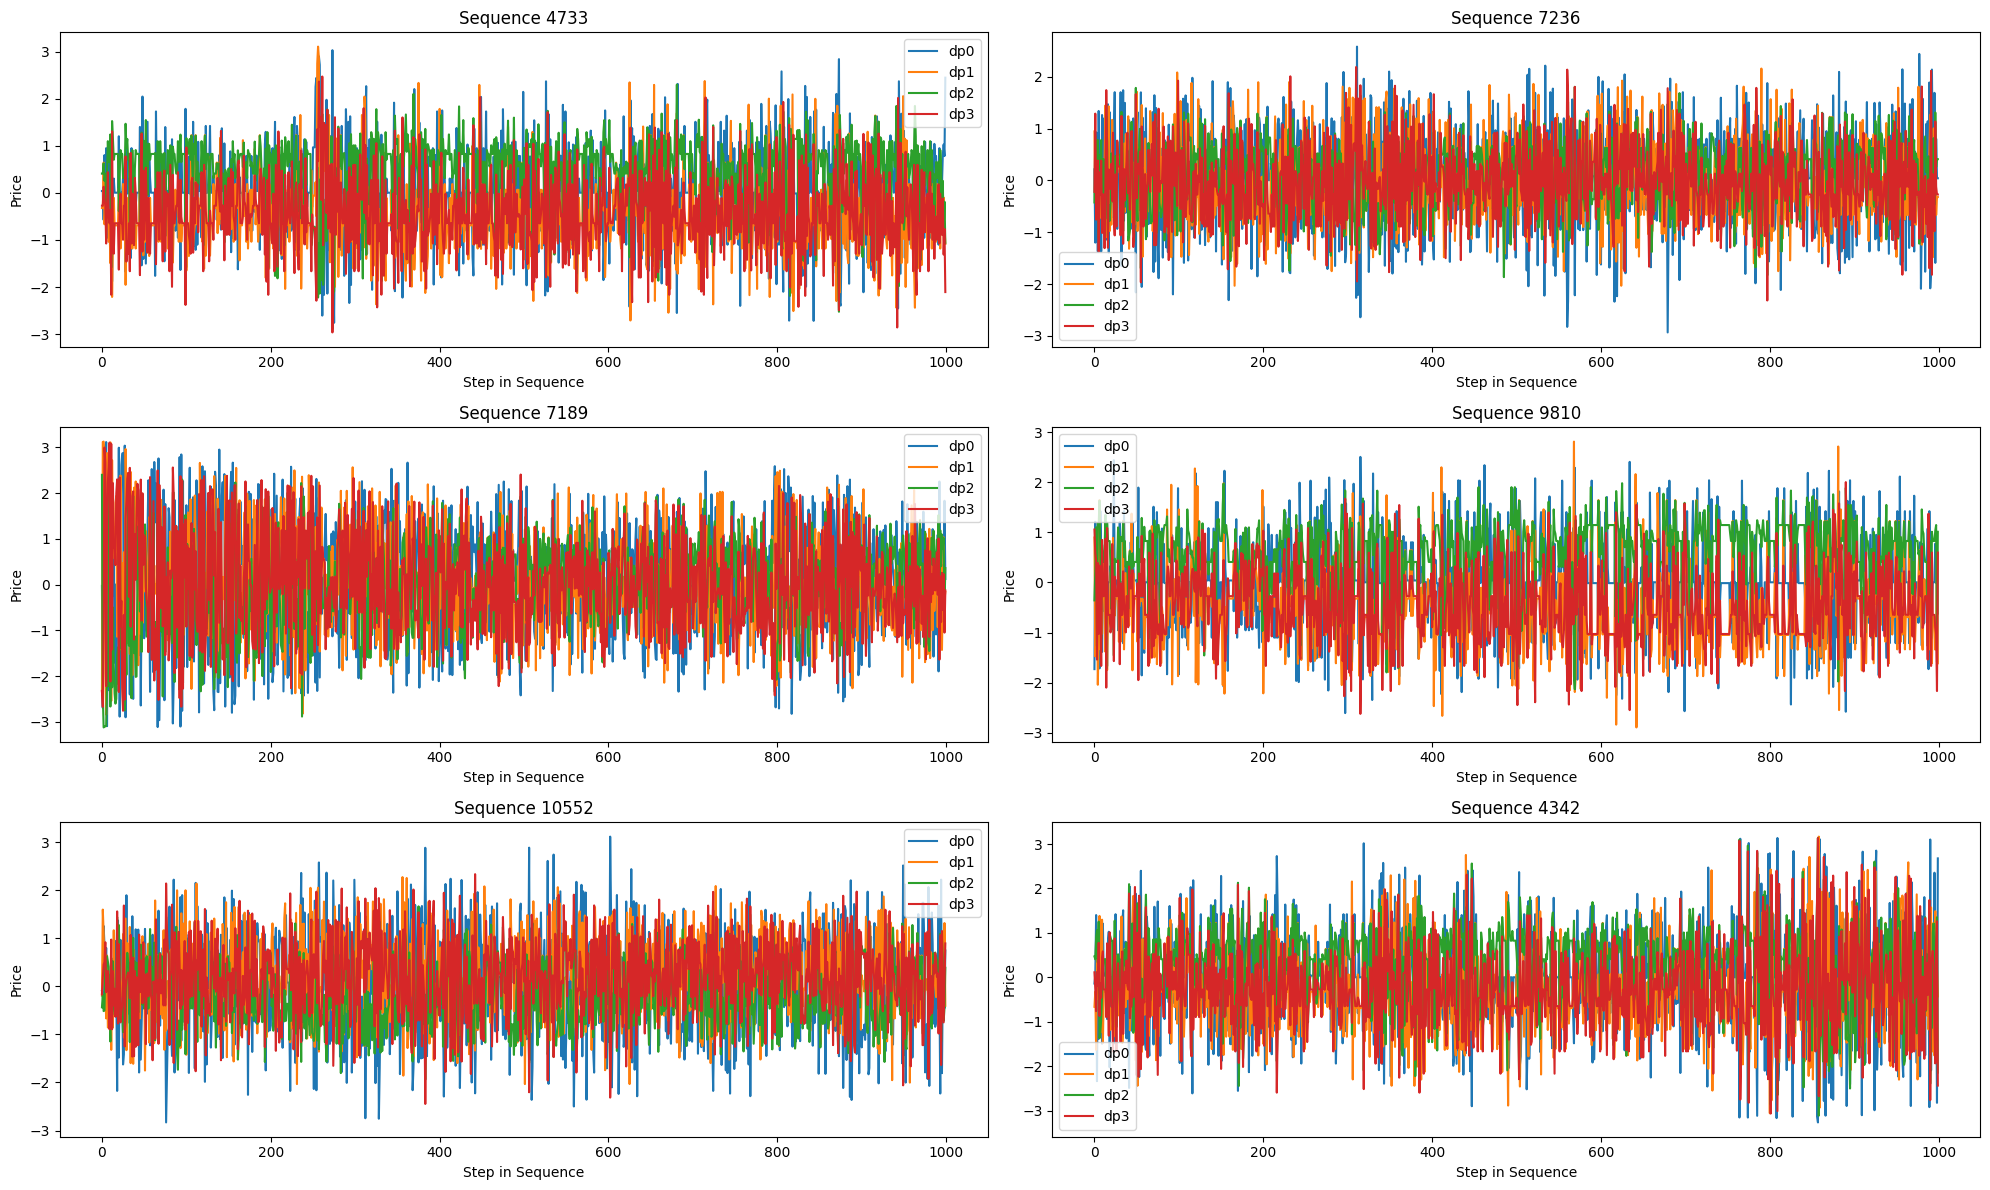

In [20]:
fig, ax = plt.subplots(figsize=(20, 12), ncols=2, nrows=3)

for i, r in enumerate(random_seq_ix):
    seq_data = trade_price_data[trade_price_data["seq_ix"] == r]

    for f in trade_price_features:
        ax[i // 2, i % 2].plot(seq_data["step_in_seq"], seq_data[f], label=f)

    ax[i // 2, i % 2].set_title(f"Sequence {r}")
    ax[i // 2, i % 2].set_xlabel("Step in Sequence")
    ax[i // 2, i % 2].set_ylabel("Price")
    ax[i // 2, i % 2].legend()
    
plt.tight_layout()